#  Решение задачи классификации при помощи пакета `torch`.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://lightning.ai/docs/torchmetrics/stable/
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://www.learnpytorch.io/02_pytorch_classification/
* https://pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler
* https://towardsdatascience.com/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb45
* https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
* https://medium.com/@zergtant/use-weighted-loss-function-to-solve-imbalanced-data-classification-problems-749237f38b7
* https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html#torch.nn.BCELoss
* https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html#torch.nn.BCEWithLogitsLoss52

## Задачи для совместного разбора

In [1]:
import torch as th

1\. Обсудите подходы к решению задачи классификации на примере синтетического датасета.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу классификации. Разделите датасет на обучающую и тестовую выборку в соотношении 80% на 20%. В качестве функции потерь используйте реализацию `CrossEntropyLoss` из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`.

Используйте модель, состоящую из двух слоев:
1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 2 нейронами.

Выведите график изменения значения функции потерь в процессе обучения. Выведите на экран значения Accuracy, Precision, Recall и F1 для обучающего и тестового множества.

Выведите на экран облако точек с цветом, соответствующим предсказаниям модели на всем датасете (и обучающей, и тестовой части).

- [ ] Проверено на семинаре


In [2]:
import torch as th
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)
X = th.FloatTensor(X)
y = th.LongTensor(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
class ClassificationModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ClassificationModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [6]:
input_dim = 2
hidden_dim = 10
output_dim = 2

In [7]:
model = ClassificationModel(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [8]:
batch_size = 32
num_epochs = 1000

In [9]:
# Создание DataLoader
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader = th.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [10]:
train_loss_history = []
test_loss_history = []

# Обучение модели
for epoch in range(num_epochs):
    # Обучение
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        # Прямой проход
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Вычисление потерь на тестовой выборке
    model.eval()
    with th.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test).item()
        test_loss_history.append(test_loss)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch [100/1000], Train Loss: 0.6946, Test Loss: 0.6935
Epoch [200/1000], Train Loss: 0.6941, Test Loss: 0.6941
Epoch [300/1000], Train Loss: 0.6946, Test Loss: 0.6938
Epoch [400/1000], Train Loss: 0.6946, Test Loss: 0.6939
Epoch [500/1000], Train Loss: 0.6943, Test Loss: 0.6937
Epoch [600/1000], Train Loss: 0.6942, Test Loss: 0.6936
Epoch [700/1000], Train Loss: 0.6942, Test Loss: 0.6937
Epoch [800/1000], Train Loss: 0.6942, Test Loss: 0.6936
Epoch [900/1000], Train Loss: 0.6936, Test Loss: 0.6938
Epoch [1000/1000], Train Loss: 0.6936, Test Loss: 0.6936


In [11]:
def calculate_metrics(model, X, y):
    model.eval()
    with th.no_grad():
        outputs = model(X)
        _, predictions = th.max(outputs, 1)

    y_true = y.detach().cpu().numpy().astype(int)
    y_pred = predictions.detach().cpu().numpy().astype(int)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return float(accuracy), float(precision), float(recall), float(f1), predictions


In [12]:
train_acc, train_prec, train_rec, train_f1, train_preds = calculate_metrics(model, X_train, y_train)

In [13]:
test_acc, test_prec, test_rec, test_f1, test_preds = calculate_metrics(model, X_test, y_test)

In [14]:
print(f"Обучающая выборка:")
print(f"  Accuracy:  {train_acc:.4f}")
print(f"  Precision: {train_prec:.4f}")
print(f"  Recall:    {train_rec:.4f}")
print(f"  F1 Score:  {train_f1:.4f}")

print(f"\nТестовая выборка:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

Обучающая выборка:
  Accuracy:  0.5100
  Precision: 0.5089
  Recall:    0.5725
  F1 Score:  0.5388

Тестовая выборка:
  Accuracy:  0.4850
  Precision: 0.4870
  Recall:    0.5600
  F1 Score:  0.5209


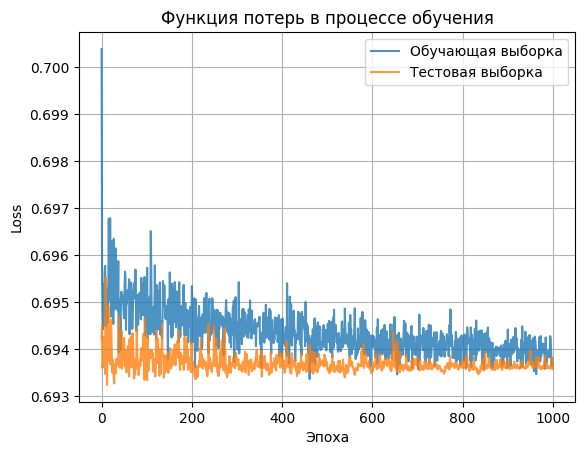

In [15]:
plt.plot(train_loss_history, label='Обучающая выборка', alpha=0.8)
plt.plot(test_loss_history, label='Тестовая выборка', alpha=0.8)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Функция потерь в процессе обучения')
plt.legend()
plt.grid()

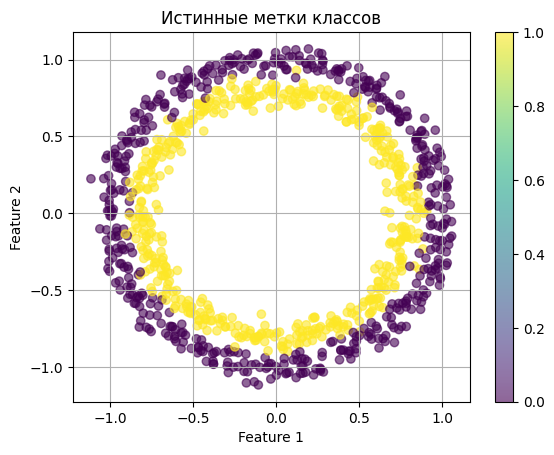

In [16]:
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Истинные метки классов')
plt.grid()
plt.colorbar(scatter)

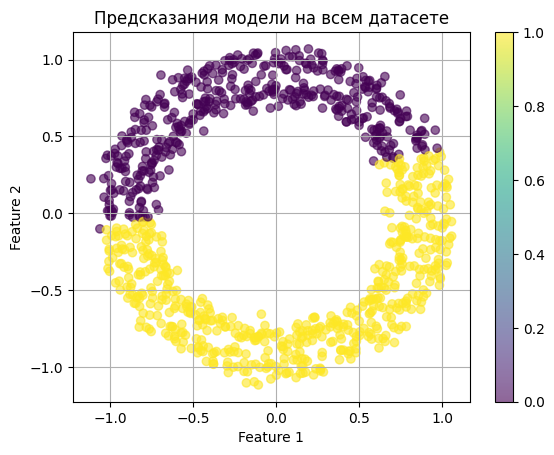

In [17]:
model.eval()
with th.no_grad():
    all_outputs = model(X)
    _, all_predictions = th.max(all_outputs, 1)

scatter = plt.scatter(X[:, 0], X[:, 1], c=all_predictions, cmap='viridis', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Предсказания модели на всем датасете')
plt.grid()
plt.colorbar(scatter)

<p class="task" id="2"></p>

2\. Повторите задачу 1, используя другую архитектуру нейронной сети.

1. Полносвязный слой с 10 нейронами;
2. Функция активации ReLU;
3. Полносвязный слой с 2 нейронами.

- [ ] Проверено на семинаре

In [18]:
import torch as th
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [19]:
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)
X = th.FloatTensor(X)
y = th.LongTensor(y)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
class ClassificationModelReLU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ClassificationModelReLU, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [22]:
input_dim = 2
hidden_dim = 10
output_dim = 2

In [23]:
model = ClassificationModelReLU(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [24]:
batch_size = 32
num_epochs = 1000

In [25]:
# Создание DataLoader
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader = th.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [26]:
train_loss_history = []
test_loss_history = []

# Обучение модели
for epoch in range(num_epochs):
    # Обучение
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        # Прямой проход
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Сохранение потерь на обучающей выборке
    avg_train_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Вычисление потерь на тестовой выборке
    model.eval()
    with th.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test).item()
        test_loss_history.append(test_loss)

    # Вывод прогресса
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}')


Epoch [100/1000], Train Loss: 0.1804, Test Loss: 0.1653
Epoch [200/1000], Train Loss: 0.0977, Test Loss: 0.0837
Epoch [300/1000], Train Loss: 0.0787, Test Loss: 0.0696
Epoch [400/1000], Train Loss: 0.0793, Test Loss: 0.0704
Epoch [500/1000], Train Loss: 0.0750, Test Loss: 0.0876
Epoch [600/1000], Train Loss: 0.0750, Test Loss: 0.0591
Epoch [700/1000], Train Loss: 0.0740, Test Loss: 0.0606
Epoch [800/1000], Train Loss: 0.0697, Test Loss: 0.0684
Epoch [900/1000], Train Loss: 0.0699, Test Loss: 0.0797
Epoch [1000/1000], Train Loss: 0.0851, Test Loss: 0.0751


In [27]:
def calculate_metrics(model, X, y):
    model.eval()
    with th.no_grad():
        outputs = model(X)
        _, predictions = th.max(outputs, 1)

    y_true = y.detach().cpu().numpy().astype(int)
    y_pred = predictions.detach().cpu().numpy().astype(int)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return float(accuracy), float(precision), float(recall), float(f1), predictions


In [28]:
train_acc, train_prec, train_rec, train_f1, train_preds = calculate_metrics(model, X_train, y_train)

In [29]:
test_acc, test_prec, test_rec, test_f1, test_preds = calculate_metrics(model, X_test, y_test)

In [30]:
print(f"Обучающая выборка:")
print(f"  Accuracy:  {train_acc:.4f}")
print(f"  Precision: {train_prec:.4f}")
print(f"  Recall:    {train_rec:.4f}")
print(f"  F1 Score:  {train_f1:.4f}")

print(f"\nТестовая выборка:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

Обучающая выборка:
  Accuracy:  0.9738
  Precision: 0.9922
  Recall:    0.9550
  F1 Score:  0.9732

Тестовая выборка:
  Accuracy:  0.9750
  Precision: 0.9798
  Recall:    0.9700
  F1 Score:  0.9749


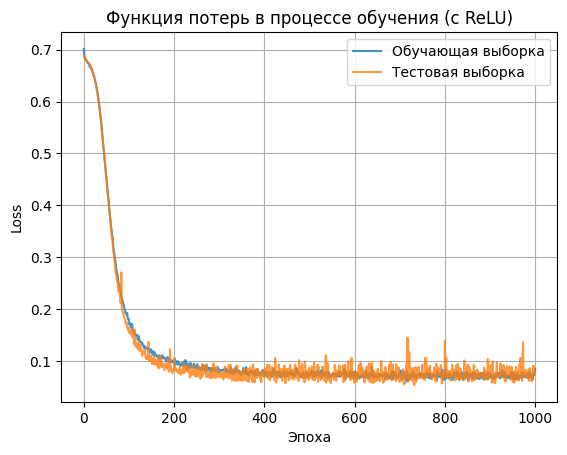

In [31]:
plt.plot(train_loss_history, label='Обучающая выборка', alpha=0.8)
plt.plot(test_loss_history, label='Тестовая выборка', alpha=0.8)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Функция потерь в процессе обучения (с ReLU)')
plt.legend()
plt.grid()

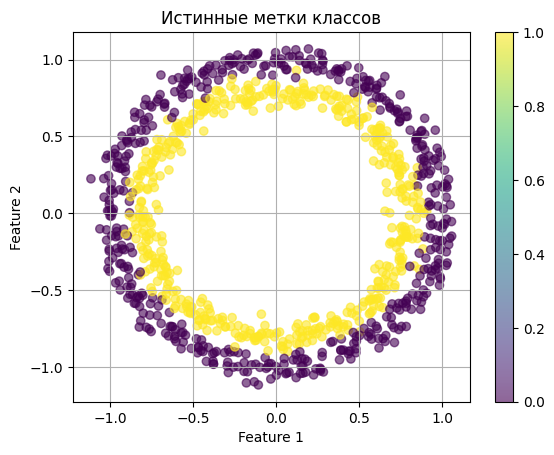

In [32]:
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Истинные метки классов')
plt.grid()
plt.colorbar(scatter)

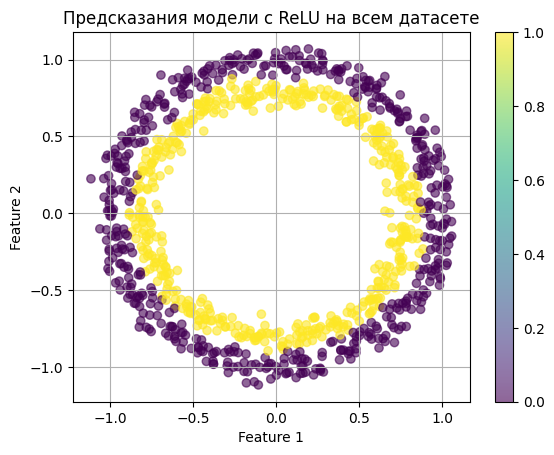

In [33]:
model.eval()
with th.no_grad():
    all_outputs = model(X)
    _, all_predictions = th.max(all_outputs, 1)

scatter = plt.scatter(X[:, 0], X[:, 1], c=all_predictions, cmap='viridis', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Предсказания модели с ReLU на всем датасете')
plt.grid()
plt.colorbar(scatter)

In [34]:
def plot_decision_boundary(model, X, y, ax, title):
    model.eval()
    with th.no_grad():
        # Создание сетки для визуализации
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))

        # Предсказания для сетки
        grid_points = th.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
        Z = model(grid_points)
        Z = th.argmax(Z, dim=1).numpy()
        Z = Z.reshape(xx.shape)

        # Построение границ
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        plt.colorbar(scatter, ax=ax)

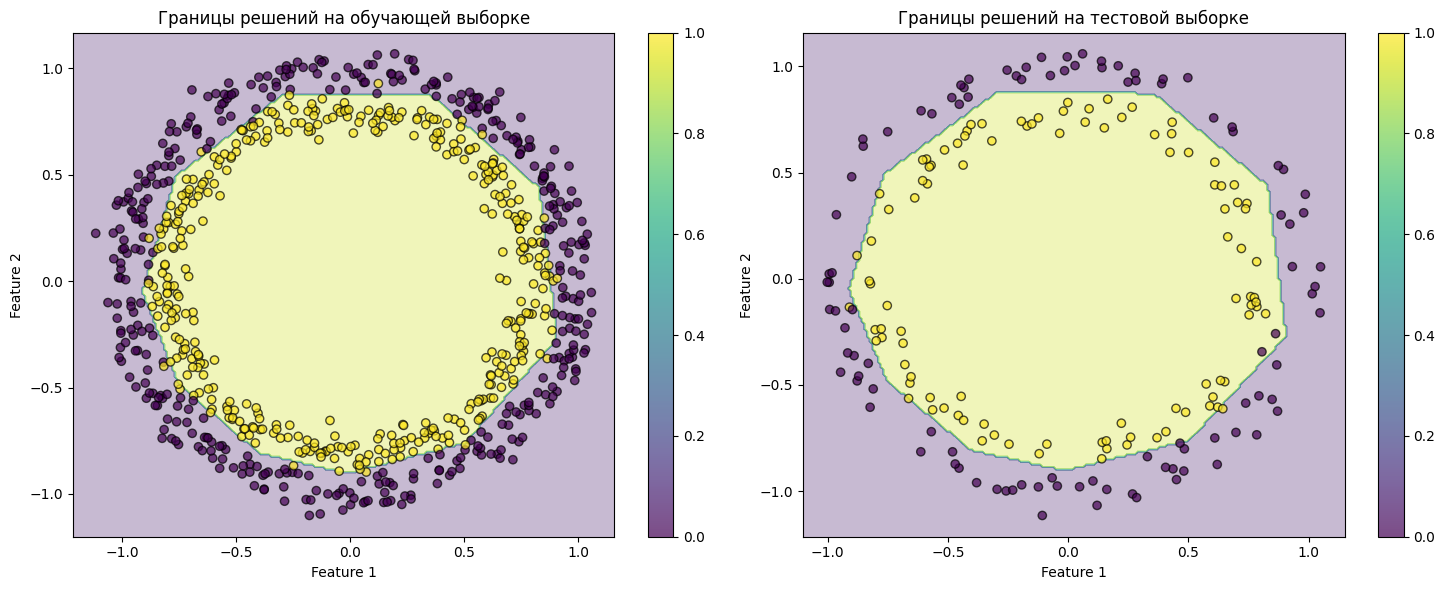

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundary(model, X_train, y_train, ax1, 'Границы решений на обучающей выборке')
plot_decision_boundary(model, X_test, y_test, ax2, 'Границы решений на тестовой выборке')

plt.tight_layout()
plt.show()

<p class="task" id="3"></p>

3\. `CrossEntropyLoss` может быть использована для задачи классификации на любое количество классов. Для задачи бинарной классификации существуют специфические функции потерь. Решите задачу 2, используя `BCEWithLogitsLoss` в качестве функции потерь.

- [ ] Проверено на семинаре

loss(x, class) = -w * [class * log(x) + (1 - class) * log(1 - x)].

In [36]:
import torch as th
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [37]:
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).unsqueeze(1)  

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
class BinaryClassificationModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(BinaryClassificationModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)  # Один выходной нейрон для бинарной классификации

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [40]:
input_dim = 2
hidden_dim = 10

In [41]:
model = BinaryClassificationModel(input_dim, hidden_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [42]:
batch_size = 32
num_epochs = 1000

In [43]:
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader = th.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [44]:
train_loss_history = []
test_loss_history = []

# Обучение модели
for epoch in range(num_epochs):
    # Обучение
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        # Прямой проход
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Сохранение потерь на обучающей выборке
    avg_train_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Вычисление потерь на тестовой выборке
    model.eval()
    with th.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test).item()
        test_loss_history.append(test_loss)

    # Вывод прогресса
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch [100/1000], Train Loss: 0.3212, Test Loss: 0.3022
Epoch [200/1000], Train Loss: 0.1341, Test Loss: 0.1072
Epoch [300/1000], Train Loss: 0.0998, Test Loss: 0.0931
Epoch [400/1000], Train Loss: 0.0919, Test Loss: 0.0726
Epoch [500/1000], Train Loss: 0.0848, Test Loss: 0.0680
Epoch [600/1000], Train Loss: 0.0797, Test Loss: 0.0741
Epoch [700/1000], Train Loss: 0.0794, Test Loss: 0.0649
Epoch [800/1000], Train Loss: 0.0838, Test Loss: 0.0579
Epoch [900/1000], Train Loss: 0.0761, Test Loss: 0.0499
Epoch [1000/1000], Train Loss: 0.0732, Test Loss: 0.0488


In [45]:
def calculate_metrics_bce(model, X, y):
    model.eval()
    with th.no_grad():
        logits = model(X)
        probabilities = th.sigmoid(logits)
        predictions = (probabilities > 0.5).long().squeeze(1)

    y_true = y.detach().cpu().numpy().astype(int).reshape(-1)
    y_pred = predictions.detach().cpu().numpy().astype(int).reshape(-1)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return float(accuracy), float(precision), float(recall), float(f1), predictions


In [46]:
train_acc, train_prec, train_rec, train_f1, train_preds = calculate_metrics_bce(model, X_train, y_train)

In [47]:
test_acc, test_prec, test_rec, test_f1, test_preds = calculate_metrics_bce(model, X_test, y_test)

In [48]:
print(f"Обучающая выборка:")
print(f"  Accuracy:  {train_acc:.4f}")
print(f"  Precision: {train_prec:.4f}")
print(f"  Recall:    {train_rec:.4f}")
print(f"  F1 Score:  {train_f1:.4f}")

print(f"\nТестовая выборка:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

Обучающая выборка:
  Accuracy:  0.9762
  Precision: 0.9974
  Recall:    0.9550
  F1 Score:  0.9757

Тестовая выборка:
  Accuracy:  0.9800
  Precision: 0.9898
  Recall:    0.9700
  F1 Score:  0.9798


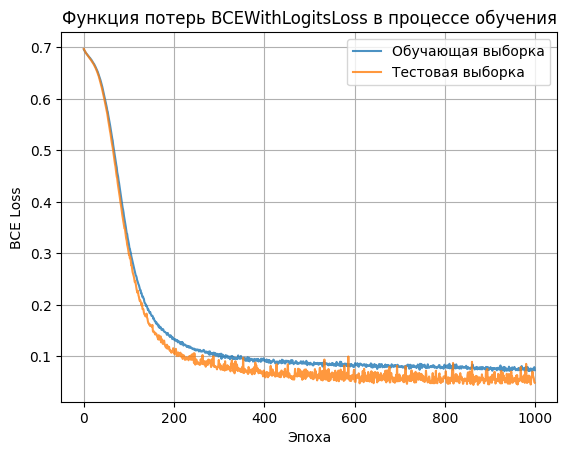

In [49]:
plt.plot(train_loss_history, label='Обучающая выборка', alpha=0.8)
plt.plot(test_loss_history, label='Тестовая выборка', alpha=0.8)
plt.xlabel('Эпоха')
plt.ylabel('BCE Loss')
plt.title('Функция потерь BCEWithLogitsLoss в процессе обучения')
plt.legend()
plt.grid()

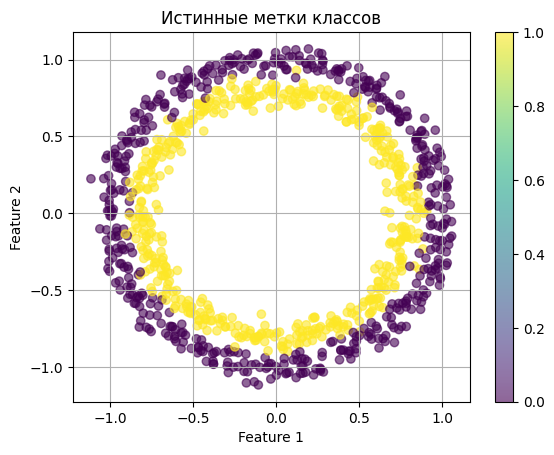

In [50]:
scatter = plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap='viridis', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Истинные метки классов')
plt.grid()
plt.colorbar(scatter)

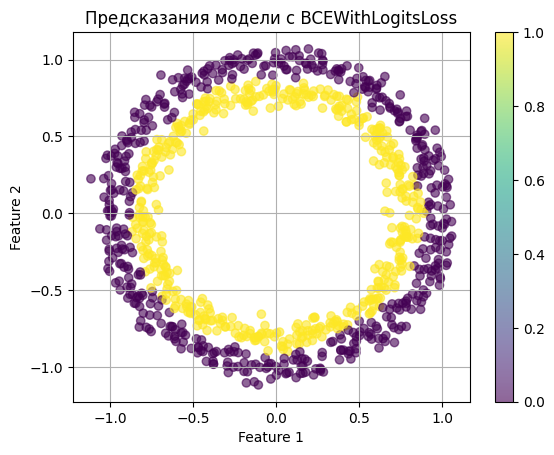

In [51]:
model.eval()
with th.no_grad():
    all_logits = model(X)
    all_probabilities = th.sigmoid(all_logits)
    all_predictions = (all_probabilities > 0.5).float()

scatter = plt.scatter(X[:, 0], X[:, 1], c=all_predictions.squeeze(), cmap='viridis', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Предсказания модели с BCEWithLogitsLoss')
plt.grid()
plt.colorbar(scatter)

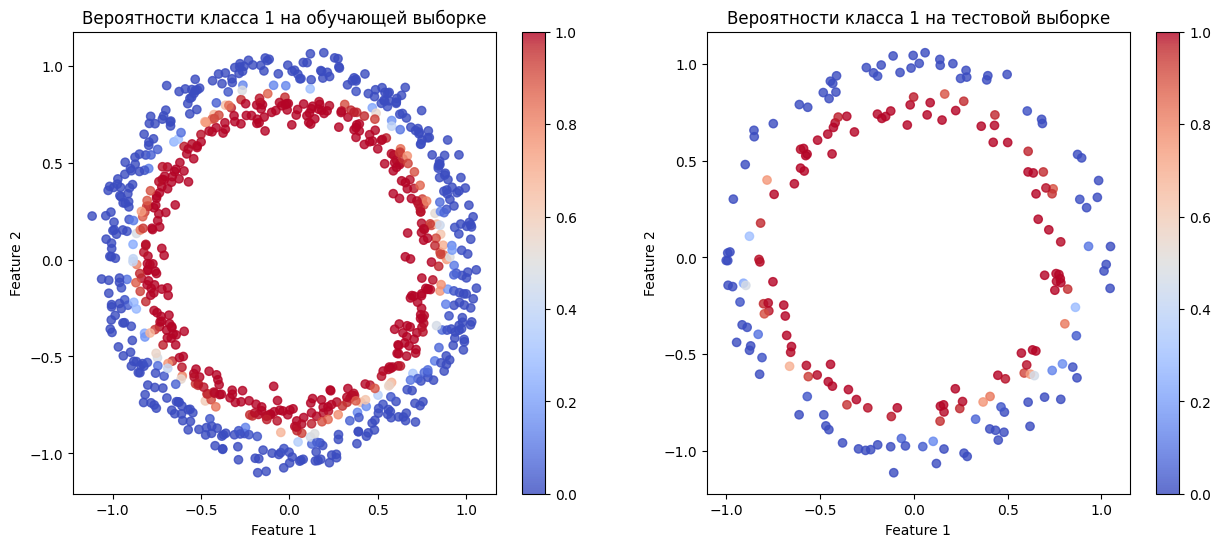

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

model.eval()
with th.no_grad():
    train_probs = th.sigmoid(model(X_train)).squeeze()
scatter1 = ax1.scatter(X_train[:, 0], X_train[:, 1], c=train_probs, cmap='coolwarm', alpha=0.8, vmin=0, vmax=1)
ax1.set_title('Вероятности класса 1 на обучающей выборке')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
plt.colorbar(scatter1, ax=ax1)

with th.no_grad():
    test_probs = th.sigmoid(model(X_test)).squeeze()
scatter2 = ax2.scatter(X_test[:, 0], X_test[:, 1], c=test_probs, cmap='coolwarm', alpha=0.8, vmin=0, vmax=1)
ax2.set_title('Вероятности класса 1 на тестовой выборке')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
plt.colorbar(scatter2, ax=ax2)

<p class="task" id="4"></p>

4\. На практике часто задача классификации является несбалансированной. В файлах каталога `imb_task` содержится несбалансированный набор данных. Обучите модель без учета несбалансированности классов (аналогично предыдущим заданиям, можно использовать любую подходящую функцию потерь). Повысьте качество модели (в смысле F1) путем модификации функции потерь (указания специального аргумента, позволяющего учесть несбалансированность классов).

- [ ] Проверено на семинаре

In [53]:
import copy
import torch as th
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter

In [54]:
X = th.load('imb_X.th')
y = th.load('imb_y.th')

In [55]:
X = X.float()
y = y.long()

In [56]:
class_counts = Counter(y.numpy())
print(f"Распределение классов: {class_counts}")
print(f"Баланс классов: {class_counts[0] / len(y):.3f} vs {class_counts[1] / len(y):.3f}")

Распределение классов: Counter({np.int64(0): 1500, np.int64(1): 150})
Баланс классов: 0.909 vs 0.091


In [57]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Train: {X_train.shape[0]}")
print(f"Validation: {X_val.shape[0]}")
print(f"Test: {X_test.shape[0]}")
print('Train class counts:', th.bincount(y_train, minlength=2).tolist())
print('Validation class counts:', th.bincount(y_val, minlength=2).tolist())
print('Test class counts:', th.bincount(y_test, minlength=2).tolist())

Train: 1056
Validation: 264
Test: 330
Train class counts: [960, 96]
Validation class counts: [240, 24]
Test class counts: [300, 30]


In [58]:
class ImbalancedModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ImbalancedModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [59]:
input_dim = X.shape[1]
hidden_dim = 64
output_dim = 1

In [60]:
def task4_binary_metrics(y_true, probs, threshold=0.5):
    y_np = y_true.detach().cpu().numpy().astype(int).reshape(-1)
    p_np = probs.detach().cpu().numpy().reshape(-1)
    pred = (p_np >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_np, pred),
        'precision': precision_score(y_np, pred, zero_division=0),
        'recall': recall_score(y_np, pred, zero_division=0),
        'f1': f1_score(y_np, pred, zero_division=0),
        'pred': pred,
    }


def task4_predict_probs(model, X_data):
    model.eval()
    with th.no_grad():
        return th.sigmoid(model(X_data)).squeeze(1).cpu()


def task4_best_threshold(y_true, probs):
    # Порог выбирается только на validation, никогда не на test.
    thresholds = np.linspace(0.15, 0.85, 71)
    scored = [
        (float(t), task4_binary_metrics(y_true, probs, float(t))['f1'])
        for t in thresholds
    ]
    return max(scored, key=lambda item: item[1])


def train_task4_model(pos_weight_value=1.0, num_epochs=400, seed=42):
    """Обучение модели и выбор лучшего checkpoint только по validation F1."""
    th.manual_seed(seed)
    model = ImbalancedModel(input_dim, hidden_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=th.tensor([float(pos_weight_value)], dtype=th.float32)
    )
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loader = th.utils.data.DataLoader(
        th.utils.data.TensorDataset(X_train, y_train),
        batch_size=32,
        shuffle=True,
        generator=th.Generator().manual_seed(seed),
    )

    train_loss_history, val_loss_history = [], []
    best_state = None
    best_val_f1 = -1.0
    best_threshold = 0.5
    best_epoch = 0

    for epoch in range(num_epochs):
        model.train()
        running = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb.float().unsqueeze(1))
            loss.backward()
            optimizer.step()
            running += loss.item() * len(yb)
        train_loss_history.append(running / len(y_train))

        model.eval()
        with th.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val.float().unsqueeze(1)).item()
        val_loss_history.append(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == num_epochs - 1:
            val_probs = task4_predict_probs(model, X_val)
            threshold, val_f1 = task4_best_threshold(y_val, val_probs)
            if val_f1 > best_val_f1:
                best_val_f1 = float(val_f1)
                best_threshold = float(threshold)
                best_epoch = epoch + 1
                best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return {
        'model': model,
        'pos_weight': float(pos_weight_value),
        'threshold': best_threshold,
        'val_f1': best_val_f1,
        'best_epoch': best_epoch,
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
    }


In [61]:
def evaluate_task4_result(result, X_data, y_data):
    probs = task4_predict_probs(result['model'], X_data)
    return task4_binary_metrics(y_data, probs, result['threshold'])


def print_task4_metrics(title, metrics):
    print(
        f"{title}: Accuracy={metrics['accuracy']:.4f}, "
        f"Precision={metrics['precision']:.4f}, "
        f"Recall={metrics['recall']:.4f}, F1={metrics['f1']:.4f}"
    )


In [62]:
# Baseline: обычный BCEWithLogitsLoss, то есть pos_weight=1.
baseline_task4 = train_task4_model(pos_weight_value=1.0, seed=42)

baseline_train_metrics = evaluate_task4_result(baseline_task4, X_train_full, y_train_full)
baseline_val_metrics = evaluate_task4_result(baseline_task4, X_val, y_val)

print('BASELINE (без учёта дисбаланса)')
print(f"Лучшая эпоха: {baseline_task4['best_epoch']}")
print(f"Порог, выбранный по validation: {baseline_task4['threshold']:.2f}")
print_task4_metrics('Train', baseline_train_metrics)
print_task4_metrics('Validation', baseline_val_metrics)


BASELINE (без учёта дисбаланса)
Лучшая эпоха: 310
Порог, выбранный по validation: 0.18
Train: Accuracy=0.8705, Precision=0.3867, Recall=0.7250, F1=0.5043
Validation: Accuracy=0.9015, Precision=0.4737, Recall=0.7500, F1=0.5806


pos_weight=1.050 | best epoch=190 | val F1=0.5846 | threshold=0.19
pos_weight=1.100 | best epoch=300 | val F1=0.5806 | threshold=0.20
pos_weight=1.200 | best epoch=190 | val F1=0.5846 | threshold=0.21
pos_weight=1.350 | best epoch=220 | val F1=0.5806 | threshold=0.24
pos_weight=1.500 | best epoch=190 | val F1=0.5846 | threshold=0.25
pos_weight=2.000 | best epoch=120 | val F1=0.5846 | threshold=0.31
pos_weight=3.000 | best epoch=110 | val F1=0.5938 | threshold=0.41
pos_weight=4.000 | best epoch=110 | val F1=0.5938 | threshold=0.48
pos_weight=5.000 | best epoch=110 | val F1=0.5938 | threshold=0.54
pos_weight=7.000 | best epoch=110 | val F1=0.5938 | threshold=0.62
pos_weight=10.000 | best epoch=400 | val F1=0.6000 | threshold=0.73

Выбрано по validation F1:
  pos_weight = 10.0000
  threshold = 0.73
  validation F1 = 0.6000

ФИНАЛЬНОЕ СРАВНЕНИЕ НА TEST
Baseline: Accuracy=0.9091, Precision=0.5000, Recall=0.7333, F1=0.5946
Weighted loss: Accuracy=0.9061, Precision=0.4884, Recall=0.7000, F1=0

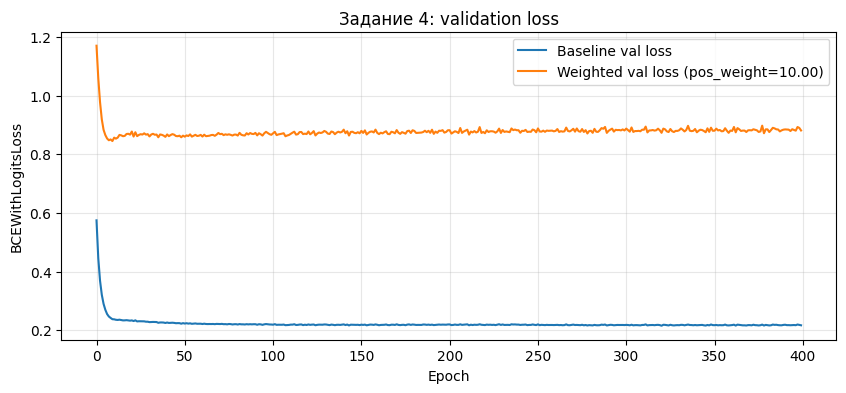

In [63]:
n_negative = int((y_train == 0).sum().item())
n_positive = int((y_train == 1).sum().item())
full_inverse_weight = n_negative / n_positive

candidate_pos_weights = sorted(set([
    1.05, 1.10, 1.20, 1.35, 1.50, 2.0, 3.0, 4.0, 5.0, 7.0, float(full_inverse_weight)
]))

weighted_candidates = []
for w in candidate_pos_weights:
    result = train_task4_model(pos_weight_value=w, seed=42)
    weighted_candidates.append(result)
    print(
        f"pos_weight={w:.3f} | best epoch={result['best_epoch']:3d} "
        f"| val F1={result['val_f1']:.4f} | threshold={result['threshold']:.2f}"
    )

best_weighted_task4 = max(weighted_candidates, key=lambda item: item['val_f1'])
print()
print('Выбрано по validation F1:')
print(f"  pos_weight = {best_weighted_task4['pos_weight']:.4f}")
print(f"  threshold = {best_weighted_task4['threshold']:.2f}")
print(f"  validation F1 = {best_weighted_task4['val_f1']:.4f}")

baseline_test_metrics = evaluate_task4_result(baseline_task4, X_test, y_test)
weighted_test_metrics = evaluate_task4_result(best_weighted_task4, X_test, y_test)

print()
print('ФИНАЛЬНОЕ СРАВНЕНИЕ НА TEST')
print_task4_metrics('Baseline', baseline_test_metrics)
print_task4_metrics('Weighted loss', weighted_test_metrics)
delta_f1_task4 = weighted_test_metrics['f1'] - baseline_test_metrics['f1']
print(f"Изменение Test F1: {delta_f1_task4:+.4f}")

if delta_f1_task4 > 0:
    print(' Модификация функции потерь повысила F1 на отложенной тестовой выборке.')
else:
    print(' На этом конкретном test split F1 не вырос, хотя pos_weight был выбран только по validation.')

# График обучения выбранных baseline и weighted моделей.
plt.figure(figsize=(10, 4))
plt.plot(baseline_task4['val_loss'], label='Baseline val loss')
plt.plot(best_weighted_task4['val_loss'], label=f"Weighted val loss (pos_weight={best_weighted_task4['pos_weight']:.2f})")
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.title('Задание 4: validation loss')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


<p class="task" id="5"></p>

5\. Повторите решение задачи 4, повысив качество модели за счет использования `WeightedRandomSampler` вместо модификации функции потерь.

- [ ] Проверено на семинаре

In [64]:
import copy
import torch as th
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler


In [65]:
X = th.load('imb_X.th').float()
y = th.load('imb_y.th').long()


In [66]:
print(f'Размер данных: X={X.shape}, y={y.shape}')
print(f'Типы данных: X={X.dtype}, y={y.dtype}')


Размер данных: X=torch.Size([1650, 2]), y=torch.Size([1650])
Типы данных: X=torch.float32, y=torch.int64


In [67]:
full_counts = th.bincount(y, minlength=2)
print(f'Распределение классов: class 0={int(full_counts[0])}, class 1={int(full_counts[1])}')
print(f'Баланс классов: {full_counts[0].item()/len(y):.3f} vs {full_counts[1].item()/len(y):.3f}')


Распределение классов: class 0=1500, class 1=150
Баланс классов: 0.909 vs 0.091


In [68]:
# Test не используется для подбора sampler/порога.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
print(f'Train: {len(y_train)}, Validation: {len(y_val)}, Test: {len(y_test)}')
print('Train class counts:', th.bincount(y_train, minlength=2).tolist())


Train: 1056, Validation: 264, Test: 330
Train class counts: [960, 96]


In [69]:
class ImbalancedModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)


In [70]:
input_dim = X.shape[1]
hidden_dim = 64
criterion_sampler = nn.BCEWithLogitsLoss()  # loss не модифицируем в задании 5
BASE_SEED = 123


In [71]:
def create_weighted_sampler(y_labels, target_positive_fraction=0.25, seed=42):
    """
    WeightedRandomSampler с управляемой долей positive в ожидаемой выборке.

    При полном inverse-frequency balancing доля positive становится ~0.5, что на этом
    датасете слишком сильно снижает precision. Здесь степень oversampling подбирается
    только по validation F1.
    """
    counts = th.bincount(y_labels, minlength=2).float()
    if (counts == 0).any():
        raise ValueError('В train должны присутствовать оба класса')
    q = float(target_positive_fraction)
    if not (0.0 < q < 1.0):
        raise ValueError('target_positive_fraction должна быть в (0, 1)')

    # Требуемое отношение суммарной вероятностной массы positive/negative = q/(1-q).
    w_neg = 1.0
    w_pos = (q / (1.0 - q)) * (counts[0] / counts[1]).item()
    class_weights = th.tensor([w_neg, w_pos], dtype=th.double)
    sample_weights = class_weights[y_labels].double()
    generator = th.Generator().manual_seed(seed)
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(y_labels), replacement=True, generator=generator
    )
    return sampler, class_weights


In [72]:
def binary_metrics_from_probs(y_true, probs, threshold=0.5):
    y_np = y_true.detach().cpu().numpy().astype(int)
    p_np = probs.detach().cpu().numpy().reshape(-1)
    pred = (p_np >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_np, pred),
        'precision': precision_score(y_np, pred, zero_division=0),
        'recall': recall_score(y_np, pred, zero_division=0),
        'f1': f1_score(y_np, pred, zero_division=0),
        'pred': pred,
    }

def predict_probs(model, X_data):
    model.eval()
    with th.no_grad():
        return th.sigmoid(model(X_data)).squeeze(1).cpu()

def best_threshold_on_validation(model, X_val, y_val):
    probs = predict_probs(model, X_val)
    thresholds = np.linspace(0.15, 0.85, 71)
    scored = [(float(t), binary_metrics_from_probs(y_val, probs, float(t))['f1']) for t in thresholds]
    return max(scored, key=lambda x: x[1])

def train_sampler_model(target_positive_fraction, num_epochs=300, seed=BASE_SEED):
    th.manual_seed(seed)
    model = ImbalancedModel(input_dim, hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    sampler, class_weights = create_weighted_sampler(
        y_train, target_positive_fraction=target_positive_fraction, seed=seed
    )
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, sampler=sampler)

    train_loss = []
    val_loss = []
    best_state = None
    best_val_f1 = -1.0
    best_threshold = 0.5

    for epoch in range(num_epochs):
        model.train()
        running = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion_sampler(logits, yb.float().unsqueeze(1))
            loss.backward()
            optimizer.step()
            running += loss.item() * len(yb)
        train_loss.append(running / len(y_train))

        model.eval()
        with th.no_grad():
            logits_val = model(X_val)
            vloss = criterion_sampler(logits_val, y_val.float().unsqueeze(1)).item()
        val_loss.append(vloss)

        # Каждые 10 эпох выбираем threshold только на validation.
        if (epoch + 1) % 10 == 0 or epoch == num_epochs - 1:
            threshold, val_f1 = best_threshold_on_validation(model, X_val, y_val)
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_threshold = threshold
                best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return {
        'model': model,
        'target_positive_fraction': target_positive_fraction,
        'class_weights': class_weights,
        'threshold': best_threshold,
        'val_f1': best_val_f1,
        'train_loss': train_loss,
        'val_loss': val_loss,
    }


In [73]:
candidate_positive_fractions = [0.15, 0.20, 0.25, 0.30, 0.35, 0.50]
sampler_candidates = []
for q in candidate_positive_fractions:
    result = train_sampler_model(q)
    sampler_candidates.append(result)
    print(
        f"target positive={q:.2f} | weight ratio w1/w0={result['class_weights'][1].item():.2f} "
        f"| best val F1={result['val_f1']:.4f} | threshold={result['threshold']:.2f}"
    )

best_sampler_result = max(sampler_candidates, key=lambda r: r['val_f1'])
print('\nВыбрано по validation F1:')
print(f"  target positive fraction = {best_sampler_result['target_positive_fraction']:.2f}")
print(f"  w1 / w0 = {best_sampler_result['class_weights'][1].item()/best_sampler_result['class_weights'][0].item():.2f}")
print(f"  decision threshold = {best_sampler_result['threshold']:.2f}")
print(f"  validation F1 = {best_sampler_result['val_f1']:.4f}")


target positive=0.15 | weight ratio w1/w0=1.76 | best val F1=0.5763 | threshold=0.27
target positive=0.20 | weight ratio w1/w0=2.50 | best val F1=0.5938 | threshold=0.40
target positive=0.25 | weight ratio w1/w0=3.33 | best val F1=0.5902 | threshold=0.51
target positive=0.30 | weight ratio w1/w0=4.29 | best val F1=0.5862 | threshold=0.58
target positive=0.35 | weight ratio w1/w0=5.38 | best val F1=0.5902 | threshold=0.57
target positive=0.50 | weight ratio w1/w0=10.00 | best val F1=0.6129 | threshold=0.73

Выбрано по validation F1:
  target positive fraction = 0.50
  w1 / w0 = 10.00
  decision threshold = 0.73
  validation F1 = 0.6129



ИТОГ ЗАДАНИЯ 5: WeightedRandomSampler vs обычная выборка
Baseline: threshold=0.18, Test Precision=0.4773, Recall=0.7000, F1=0.5676
Sampler : target_pos=0.50, threshold=0.73, Test Precision=0.4889, Recall=0.7333, F1=0.5867
Изменение Test F1: +0.0191
WeightedRandomSampler повысил F1 на отложенной тестовой выборке.

Первые 5 sampler-батчей:
  batch 1: class 0=19, class 1=13
  batch 2: class 0=14, class 1=18
  batch 3: class 0=7, class 1=25
  batch 4: class 0=23, class 1=9
  batch 5: class 0=11, class 1=21
Вес примера класса 0: 1.000000
Вес примера класса 1: 10.000000
Отношение w1/w0: 10.00:1


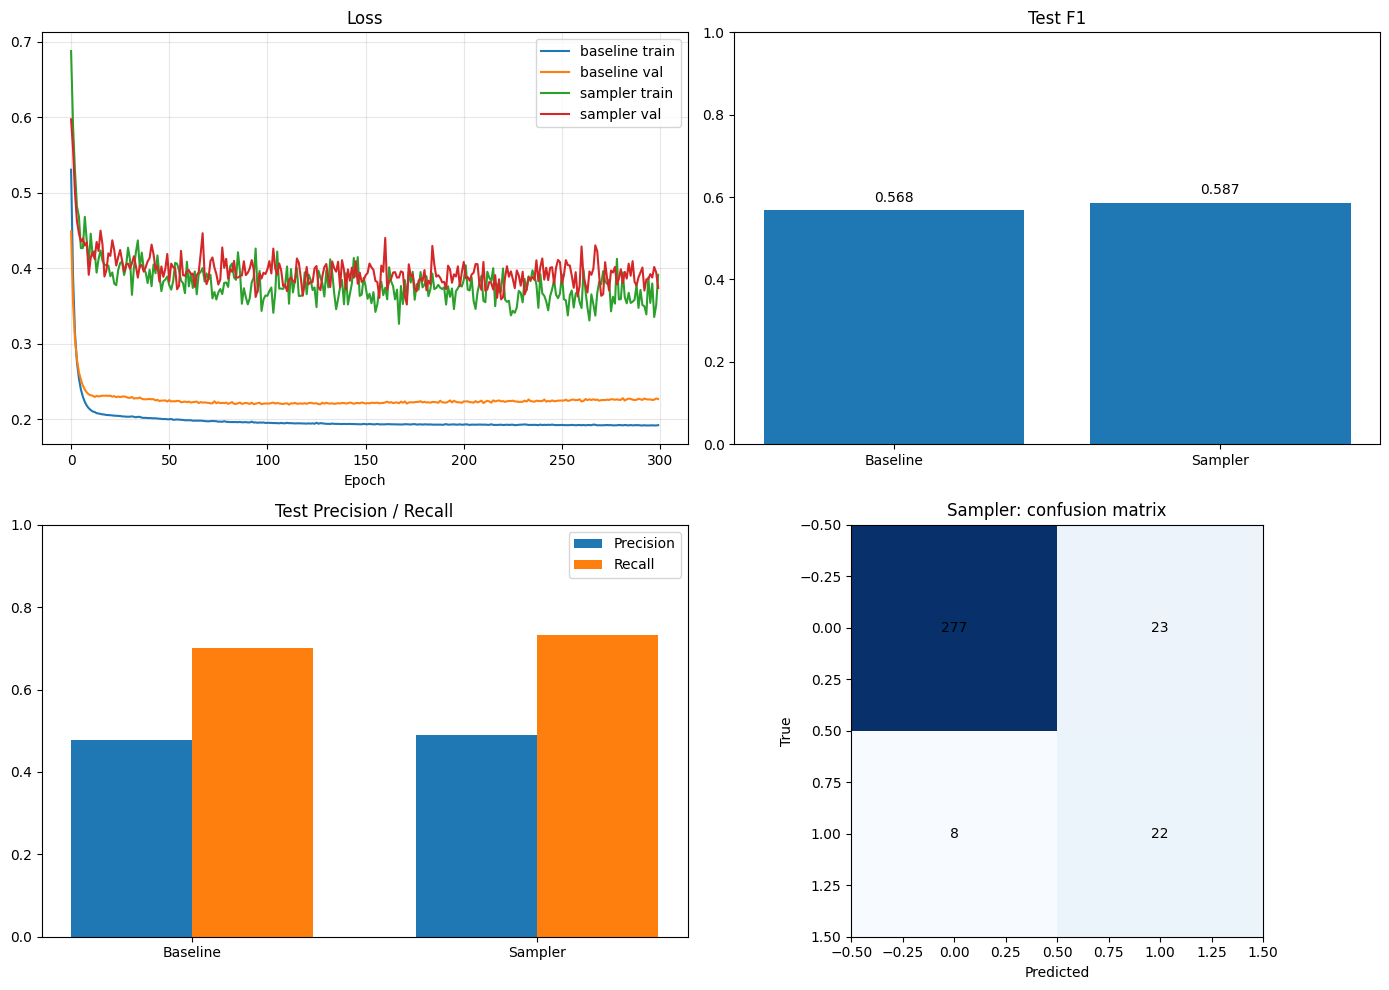

In [74]:
# Финальная оценка на test выполняется только один раз после выбора sampler по validation.
model_sampler = best_sampler_result['model']
best_threshold = best_sampler_result['threshold']
test_probs_sampler = predict_probs(model_sampler, X_test)
sampler_test_metrics = binary_metrics_from_probs(y_test, test_probs_sampler, best_threshold)
train_probs_sampler = predict_probs(model_sampler, X_train_full)
sampler_train_metrics = binary_metrics_from_probs(y_train_full, train_probs_sampler, best_threshold)

th.manual_seed(BASE_SEED)
baseline_model = ImbalancedModel(input_dim, hidden_dim)
baseline_opt = optim.Adam(baseline_model.parameters(), lr=0.001)
baseline_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True,
                             generator=th.Generator().manual_seed(BASE_SEED))
baseline_train_loss, baseline_val_loss = [], []
best_base_state, best_base_f1, best_base_threshold = None, -1.0, 0.5
for epoch in range(300):
    baseline_model.train()
    running = 0.0
    for xb, yb in baseline_loader:
        baseline_opt.zero_grad()
        logits = baseline_model(xb)
        loss = criterion_sampler(logits, yb.float().unsqueeze(1))
        loss.backward()
        baseline_opt.step()
        running += loss.item() * len(yb)
    baseline_train_loss.append(running / len(y_train))
    with th.no_grad():
        lv = criterion_sampler(baseline_model(X_val), y_val.float().unsqueeze(1)).item()
    baseline_val_loss.append(lv)
    if (epoch + 1) % 10 == 0 or epoch == 299:
        t, vf1 = best_threshold_on_validation(baseline_model, X_val, y_val)
        if vf1 > best_base_f1:
            best_base_f1, best_base_threshold = vf1, t
            best_base_state = copy.deepcopy(baseline_model.state_dict())
baseline_model.load_state_dict(best_base_state)
baseline_test_probs = predict_probs(baseline_model, X_test)
baseline_test_metrics = binary_metrics_from_probs(y_test, baseline_test_probs, best_base_threshold)

print('\n' + '='*68)
print('ИТОГ ЗАДАНИЯ 5: WeightedRandomSampler vs обычная выборка')
print('='*68)
print(f"Baseline: threshold={best_base_threshold:.2f}, Test Precision={baseline_test_metrics['precision']:.4f}, "
      f"Recall={baseline_test_metrics['recall']:.4f}, F1={baseline_test_metrics['f1']:.4f}")
print(f"Sampler : target_pos={best_sampler_result['target_positive_fraction']:.2f}, threshold={best_threshold:.2f}, "
      f"Test Precision={sampler_test_metrics['precision']:.4f}, Recall={sampler_test_metrics['recall']:.4f}, "
      f"F1={sampler_test_metrics['f1']:.4f}")
delta_f1 = sampler_test_metrics['f1'] - baseline_test_metrics['f1']
print(f'Изменение Test F1: {delta_f1:+.4f}')
if delta_f1 > 0:
    print('WeightedRandomSampler повысил F1 на отложенной тестовой выборке.')
else:
    print('На данном split sampler не улучшил Test F1; параметры выбирались без использования test.')

selected_sampler, selected_class_weights = create_weighted_sampler(
    y_train, best_sampler_result['target_positive_fraction'], seed=777
)
balance_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, sampler=selected_sampler)
print('\nПервые 5 sampler-батчей:')
for i, (_, by) in enumerate(balance_loader):
    if i == 5:
        break
    bc = th.bincount(by, minlength=2)
    print(f'  batch {i+1}: class 0={int(bc[0])}, class 1={int(bc[1])}')
print(f"Вес примера класса 0: {selected_class_weights[0].item():.6f}")
print(f"Вес примера класса 1: {selected_class_weights[1].item():.6f}")
print(f"Отношение w1/w0: {selected_class_weights[1].item()/selected_class_weights[0].item():.2f}:1")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(baseline_train_loss, label='baseline train')
axes[0,0].plot(baseline_val_loss, label='baseline val')
axes[0,0].plot(best_sampler_result['train_loss'], label='sampler train')
axes[0,0].plot(best_sampler_result['val_loss'], label='sampler val')
axes[0,0].set_title('Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend(); axes[0,0].grid(alpha=.3)

names = ['Baseline', 'Sampler']
f1s = [baseline_test_metrics['f1'], sampler_test_metrics['f1']]
axes[0,1].bar(names, f1s)
axes[0,1].set_ylim(0, 1); axes[0,1].set_title('Test F1')
for i,v in enumerate(f1s): axes[0,1].text(i, v+0.02, f'{v:.3f}', ha='center')

x = np.arange(2); width=.35
axes[1,0].bar(x-width/2, [baseline_test_metrics['precision'], sampler_test_metrics['precision']], width, label='Precision')
axes[1,0].bar(x+width/2, [baseline_test_metrics['recall'], sampler_test_metrics['recall']], width, label='Recall')
axes[1,0].set_xticks(x, names); axes[1,0].set_ylim(0,1); axes[1,0].legend(); axes[1,0].set_title('Test Precision / Recall')

cm = confusion_matrix(y_test.numpy(), sampler_test_metrics['pred'])
im = axes[1,1].imshow(cm, cmap='Blues')
axes[1,1].set_title('Sampler: confusion matrix')
axes[1,1].set_xlabel('Predicted'); axes[1,1].set_ylabel('True')
for r in range(2):
    for c in range(2): axes[1,1].text(c, r, str(cm[r,c]), ha='center', va='center')
plt.tight_layout()
plt.show()


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ